# EUbOPEN → AnnData

Builds an AnnData object from the [Cell Painting dataset of EUbOPEN compounds](https://zenodo.org/records/10894238) (Sumia, Servier R&D Institute Paris-Saclay, CC-BY-4.0).
One observation is a well, one variable is a CellProfiler feature.

U2OS cells, 8 doses on 105 plates across four runs, distributed as one 2.3 GB parquet file:

```bash
curl -L -o hcs_cellpainting_eubopen.parquet \
  "https://zenodo.org/api/records/10894238/files/hcs_cellpainting_eubopen(1).parquet/content"
```

In [1]:
from __future__ import annotations

from pathlib import Path

import numpy as np
import pandas as pd
import scanpy as sc

import cell_painting_io as cpio

PROFILES = Path("~/data/2024_EUbOPEN_CellPainting/hcs_cellpainting_eubopen.parquet").expanduser()

## Missing values are encoded as -9999

There are no NaN in this file; missing measurements are written as `-9999`, which would otherwise enter the matrix as a real value.
The sentinel differs between datasets, so it is a parameter rather than an assumption.

In [2]:
adata = cpio.read_profiles(PROFILES, sentinels=-9999, index_columns=("id_plate", "id_well"))

missing = np.isnan(adata.X)
print(f"{adata.n_obs:,} wells x {adata.n_vars:,} features")
print(f"missing: {missing.sum():,} values ({missing.mean():.1%})")
print(f"features with any missing: {missing.any(axis=0).sum():,}")
print(f"features entirely missing: {missing.all(axis=0).sum():,}")

39,206 wells x 7,703 features
missing: 72,554,330 values (24.0%)
features with any missing: 2,760
features entirely missing: 1,064


## Case-duplicated columns

55 features appear twice differing only in capitalisation, such as `Nuclei_Correlation_Manders_AGP_DNA` and `nuclei_correlation_manders_agp_dna`.
The pairs are not copies: the capitalised member is sentinel-filled where the lower-case one holds values.
Keeping only complete features removes all of them.

In [3]:
lowercased = pd.Index([name.lower() for name in adata.var_names])
print(f"case-duplicated names before: {int(lowercased.duplicated().sum())}")

adata = cpio.drop_incomplete_features(adata)
lowercased = pd.Index([name.lower() for name in adata.var_names])
print(f"{adata.n_vars:,} complete features, {int(lowercased.duplicated().sum())} case-duplicates left")

case-duplicated names before: 55


4,943 complete features, 0 case-duplicates left


## Annotation

The same name grammar as CPJUMP1, lower-cased and with the channel late in the name, so the shared parser handles both.
`image` joins `cells`, `cytoplasm` and `nuclei`: whole-image measurements not tied to a segmented object.

In [4]:
cpio.annotate_features(adata.var)
cpio.categorize(adata, ["id_plate", "id_batch", "perturbator_type", "control_type", "concentration_unit"])
adata.var

,compartment,family,channel,channel_2,n_channels
feature,,,,,
image_granularity_10_agp,image,granularity,agp,NaN,1
image_granularity_10_bfhigh,image,granularity,brightfield_high,NaN,1
image_granularity_10_bflow,image,granularity,brightfield_low,NaN,1
image_granularity_10_brightfield,image,granularity,brightfield,NaN,1
image_granularity_10_dna,image,granularity,dna,NaN,1
...,...,...,...,...,...
nuclei_texture_variance_rna_3_03_256,nuclei,texture,rna,NaN,1
nuclei_texture_variance_rna_5_00_256,nuclei,texture,rna,NaN,1
nuclei_texture_variance_rna_5_01_256,nuclei,texture,rna,NaN,1


In [5]:
adata.var.value_counts(["compartment", "n_channels"]).unstack(fill_value=0)

n_channels,1,0,2
compartment,,,
cells,1131,31,124
cytoplasm,1077,21,122
image,1126,73,0
nuclei,1130,29,79


## Sanity checks

In [6]:
print(f"plates: {adata.obs['id_plate'].nunique()} | runs: {adata.obs['id_batch'].nunique()}")
print(f"perturbagen ids: {adata.obs['id_perturbator'].nunique()} (Zenodo advertises 595 compounds)")
print(f"non-finite values: {int((~np.isfinite(adata.X)).sum())}")
print(adata.obs.groupby("perturbator_type", observed=True)["control_type"].value_counts(dropna=False))

plates: 105 | runs: 4
perturbagen ids: 575 (Zenodo advertises 595 compounds)
non-finite values: 0
perturbator_type  control_type
control           poscon           3769
                  negcon           3715
                  nan                 0
trt               nan             31722
                  poscon              0
                  negcon              0
Name: count, dtype: int64


The treated wells carry nine concentrations for eight doses: two of them are the same dose written at different precision.

In [7]:
sorted(adata.obs.loc[adata.obs["perturbator_type"] == "trt", "concentration"].unique())

[np.float64(3.125e-06),
 np.float64(1e-05),
 np.float64(3.125e-05),
 np.float64(3.13e-05),
 np.float64(0.0001),
 np.float64(0.0003125),
 np.float64(0.001),
 np.float64(0.003125),
 np.float64(0.01)]

In [8]:
adata.write_h5ad(PROFILES.with_name("eubopen.h5ad"))

## Already normalized

These profiles arrive plate-normalized against the negative controls, which the negative controls themselves show: on every plate they sit at unit standard deviation and near-zero mean.
So they enter PCA as they are, like the CPJUMP1 profiles.
The much larger spread over all wells is treated wells responding, not unnormalized features.

In [9]:
negcon = adata[adata.obs["control_type"] == "negcon"]
per_plate = pd.DataFrame(
    {
        "negcon_mean": [negcon[negcon.obs["id_plate"] == p].X.mean() for p in negcon.obs["id_plate"].unique()[:5]],
        "negcon_std": [negcon[negcon.obs["id_plate"] == p].X.std() for p in negcon.obs["id_plate"].unique()[:5]],
    }
)
print(per_plate.round(3).to_string(index=False))
print(f"\nall wells: mean {adata.X.mean():.3f}, std {adata.X.std():.3f}")

negcon_mean  negcon_std
 0.08493398       1.005
 0.09391752       1.007
0.115536205       1.006
 0.10148031       1.008
0.106652915       1.012

all wells: mean 0.180, std 8.028


In [10]:
sc.pp.pca(adata, n_comps=50)
sc.pp.neighbors(adata, n_neighbors=15)
sc.tl.umap(adata)

/home/lheumos/miniforge3/envs/cell-painting-io/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## What drives the embedding

How often do neighbouring wells share a label, against the rate expected if labels were shuffled?

In [11]:
cpio.neighbour_enrichment(adata, ["id_plate", "id_batch", "perturbator_type", "concentration"])

,observed,baseline,ratio
covariate,,,
id_plate,0.136,0.010,14.099
id_batch,0.546,0.283,1.929
perturbator_type,0.795,0.691,1.151
concentration,0.337,0.132,2.548


Plate dominates by an order of magnitude, far above anything biological.
Dose comes next and treated-versus-control is barely above chance, which is what a dose-response screen should look like: most wells sit at concentrations too low to move cells, so being treated says little on its own.

## Do the controls separate?

Not obviously by eye, so measure it among control wells only, where a coin flip would give 0.5.

In [12]:
controls = adata[adata.obs["control_type"].isin(["negcon", "poscon"])].copy()
controls.obs["control_type"] = controls.obs["control_type"].cat.remove_unused_categories()
sc.pp.neighbors(controls, n_neighbors=15)
cpio.neighbour_enrichment(controls, ["control_type"])

,observed,baseline,ratio
covariate,,,
control_type,0.733,0.5,1.467


Real but modest, and it does not improve under per-plate renormalization, global scaling or outlier clipping.
Two things limit it.
Plate structure is an order of magnitude stronger than any treatment effect, so the embedding spends its geometry on plates.
And `poscon` is not one phenotype: it is eight compounds with eight mechanisms, against a single DMSO negative control, so there is no reason for positive controls to land in one place.

In [13]:
print(adata.obs.loc[adata.obs["control_type"] == "poscon", "perturbator_name"].value_counts().to_string())

perturbator_name
quinidine                          486
dexamethasone                      485
NVS-PAK1-1                         483
TC-S-7004                          483
aloxistatin                        463
FK-866                             457
LY2109761                          457
AMG-900                            455
4-P-PDOT                             0
6-Chloromelatonin                    0
640                                  0
(+)-JQ1                              0
(R)-9s                               0
(R)-ZINC 3573                        0
(R)-a-methylhistamine                0
(S)-9s                               0
(S)-ZINC 3573                        0
A 127722                             0
A 971432                             0
A 987306                             0
A-079                                0
A-108                                0
A-196                                0
A-226                                0
A-366                                0
A-485   

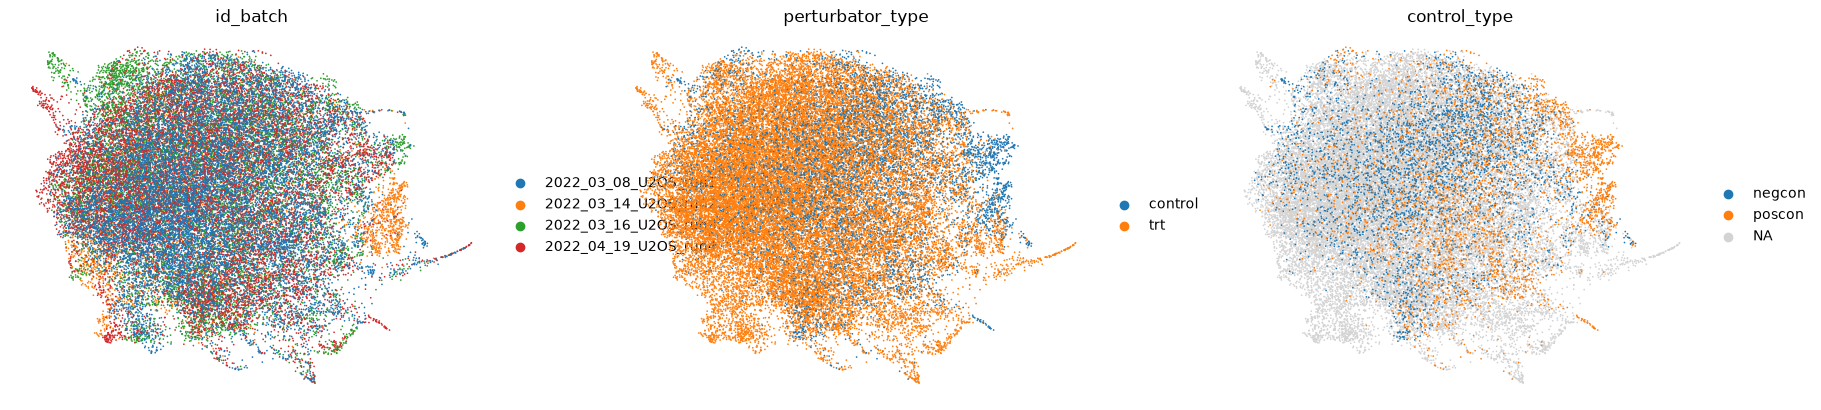

In [14]:
sc.pl.umap(adata, color=["id_batch", "perturbator_type", "control_type"], ncols=3, frameon=False, size=6)